# **What type of resale unit and duration allows the owner to obtain the largest profit upon selling?**
For this question, we choose to use the XGBoost model as it was evaluated to be the most accurate model as per the evaluation.md. Hence the initial few code chunks are simply copied over from the XGBoost model notebook under the model_training folder

We then need to break down the question.

Profit
Since we do not have available data on the original initial purchase price of the resale flats, we have to make the assumption that an owner would have had to buy their current flat as a resale as well. The profit cannot be seen directly using the dataset as the dataset only tracks units that have been sold. If a unit has been bought only once during this period and was not sold off, the unit will only appear once, which would not show its resale value even in later dates. Hence, we use a machine learning model to predict its resale price after a certain duration to then derive the greatest profit

Hence, profit will be defined as: Predicted Resale Value - Initial Purchased Resale Value

Duration
We are simply predicting the possible price of the flat k years into the future. We must also consider that remaining lease is an important factor as it limits how long an owner can hold their unit. To be conservative, we will set a minimum resaleable lease of 20 years, below which flats would realistically be hard to resell and have little resale value. Another thing to consider is the depreciation of the units over time. Since the XGBoost model was trained on empirical resale transactions (2017–2024), where lease decay effects are already reflected in observed prices, we will not add an additional depreciation factor to avoid double counted.

Type of Unit
The relevant types of unit that we will consider are their maturity (mature/non-mature), storey and floor area.


# **Import Required Libraries**

In [19]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# **Load and Preprocess Data**
We split the dataset into train-test and applying one-hot encoding to categorical features.

In [20]:
# Load Data
df = pd.read_csv('../datasets/Final_ResaleData.csv')

# Split Dataset into Train (80%) and Test (20%) Sets
X = df.drop(columns=['Price'])
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Final Model**
We create and train the final model to answer this question. Since XGBoost has the lowest MAE, RMSE and highest R^2, we chose it to be the model.

In [21]:
best_xgb_model = XGBRegressor(
    n_estimators=250,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    tree_method='hist',
    random_state=42
)

best_xgb_model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=250,
             n_jobs=None, num_parallel_tree=None, ...)

# **Prediction**

In this section, we simulate future resale prices, taking into account depreciation and remaining lease time.

In [22]:
df["Predicted_Current_Price"] = best_xgb_model.predict(X)

durations = range(1, 16)

for k in durations:
    df_future = df.copy()
    df_future["Year"] = df_future["Year"] + k
    df_future["Future_Remaining_Lease"] = df_future["Remaining_Lease"] - k
    
    # Filter out expired or near-expiry flats
    df_future = df_future[df_future["Future_Remaining_Lease"] > 20]
    
    # Predict resale price k years later using trained XGBoost
    df_future[f"Predicted_Price_{k}yr"] = best_xgb_model.predict(df_future[X.columns])
    
    # Compute profit
    df_future[f"Profit_{k}yr"] = df_future[f"Predicted_Price_{k}yr"] - df_future["Price"]
    
    # Merge profit back into main dataframe
    df = df.merge(df_future[[f"Profit_{k}yr"]], left_index=True, right_index=True, how="left")





# **Aggregation of Prices for Unit Types**

We compute the average profit across durations (1–15 years), grouped by:
- Mature (estate type)
- Storey
- Floor_Area bins (to represent unit type/size)
- Remaining_Lease bands (to check interaction effects)

We also show the profits normalised by unit sizes, to show the profit gains by percentage as well 

In [23]:
# Create floor area bins (to represent approximate unit types)
df["Floor_Area_Range"] = pd.cut(
    df["Floor_Area"],
    bins=[0, 60, 80, 100, 120, 140, 160, 200],
    labels=["<60", "60–80", "80–100", "100–120", "120–140", "140–160", ">160"]
)

# Collect profit columns dynamically (for 1–15 years)
profit_cols = [f"Profit_{k}yr" for k in range(1, 16)]

# Aggregation 1 — by maturity and storey
profit_by_maturity_storey = (
    df.groupby(["Mature", "Storey"])[profit_cols]
      .mean()
      .round(0)
)

# Aggregation 2 — by floor area (proxy for unit type)
profit_by_area = (
    df.groupby("Floor_Area_Range")[profit_cols]
      .mean()
      .round(0)
)

# Aggregation 3 — by maturity and floor area combined
profit_by_maturity_area = (
    df.groupby(["Mature", "Floor_Area_Range"])[profit_cols]
      .mean()
      .round(0)
)
# Calculate profit percentages for each duration

for k in range(1, 16):
    df[f"ProfitPct_{k}yr"] = (df[f"Profit_{k}yr"] / df["Price"]) * 100

profitpct_by_maturity_area = (
    df.groupby(["Mature", "Floor_Area_Range"])[[f"ProfitPct_{k}yr" for k in range(1, 16)]]
      .mean()
      .round(2)
)

# Display a few summaries
display(profit_by_maturity_storey.head(10))
display(profit_by_area)
display(profit_by_maturity_area)
display(profitpct_by_maturity_area)


C:\Users\cavan\AppData\Local\Temp\ipykernel_46344\363788586.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Floor_Area_Range")[profit_cols]
C:\Users\cavan\AppData\Local\Temp\ipykernel_46344\363788586.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Mature", "Floor_Area_Range"])[profit_cols]
C:\Users\cavan\AppData\Local\Temp\ipykernel_46344\363788586.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence t

Profit_1yr  Profit_2yr  Profit_3yr  Profit_4yr  Profit_5yr  \
Mature Storey                                                               
False  1          26356.0     53055.0     78567.0    101296.0    117340.0   
       4          26866.0     53978.0     80069.0    103403.0    119859.0   
       7          27013.0     53888.0     80097.0    104040.0    121086.0   
       10         27621.0     55299.0     82414.0    107067.0    124722.0   
       13         30482.0     60034.0     88634.0    114455.0    133325.0   
       16         31748.0     62736.0     91896.0    118301.0    136814.0   
       19         29387.0     58231.0     85808.0    111471.0    129539.0   
       22         27473.0     58428.0     88849.0    117757.0    138934.0   
       25         30909.0     60677.0     86149.0    110464.0    130065.0   
       28         25304.0     45266.0     64846.0     84712.0     98603.0   

               Profit_6yr  Profit_7yr  Profit_8yr  Profit_9yr  Profit_10yr  \
Mature Storey                                                                
False  1         127999.0    134922.0    138066.0    138066.0     138066.0   
       4         130931.0    138087.0    141430.0    141430.0     141430.0   
       7         132437.0    140259.0    143916.0    143916.0     143916.0   
       10        136411.0    144433.0    148098.0    148098.0     148098.0   
       13        145449.0    153553.0    156864.0    156864.0     156864.0   
       16        148509.0    156150.0    159599.0    159599.0     159599.0   
       19        140343.0    147112.0    150302.0    150302.0     150302.0   
       22        152211.0    160584.0    163742.0    163742.0     163742.0   
       25        141033.0    148628.0    152049.0    152049.0     152049.0   
       28        108291.0    115809.0    118828.0    118828.0     118828.0   

               Profit_11yr  Profit_12yr  Profit_13yr  Profit_14yr  Profit_15yr  
Mature Storey                                                                   
False  1          138066.0     138066.0     138066.0     138066.0     138066.0  
       4          141430.0     141430.0     141430.0     141430.0     141430.0  
       7          143916.0     143916.0     143916.0     143916.0     143916.0  
       10         148098.0     148098.0     148098.0     148098.0     148098.0  
       13         156864.0     156864.0     156864.0     156864.0     156864.0  
       16         159599.0     159599.0     159599.0     159599.0     159599.0  
       19         150302.0     150302.0     150302.0     150302.0     150302.0  
       22         163742.0     163742.0     163742.0     163742.0     163742.0  
       25         152049.0     152049.0     152049.0     152049.0     152049.0  
       28         118828.0     118828.0     118828.0     118828.0     118828.0

,Profit_1yr,Profit_2yr,Profit_3yr,Profit_4yr,Profit_5yr,Profit_6yr,Profit_7yr,Profit_8yr,Profit_9yr,Profit_10yr,Profit_11yr,Profit_12yr,Profit_13yr,Profit_14yr,Profit_15yr
Floor_Area_Range,,,,,,,,,,,,,,,
<60,14199.0,29153.0,43399.0,56560.0,66431.0,72885.0,76843.0,79007.0,79007.0,79007.0,79007.0,79007.0,79007.0,79007.0,79007.0
60–80,18738.0,37971.0,56950.0,74503.0,87212.0,96259.0,102415.0,105710.0,105710.0,105710.0,105710.0,105710.0,105710.0,105710.0,105710.0
80–100,28610.0,56241.0,82135.0,105295.0,122661.0,133965.0,141372.0,144542.0,144542.0,144542.0,144542.0,144542.0,144542.0,144542.0,144542.0
100–120,29061.0,58736.0,87950.0,114431.0,133590.0,146707.0,155967.0,159939.0,159939.0,159939.0,159939.0,159939.0,159939.0,159939.0,159939.0
120–140,30077.0,62436.0,95635.0,126728.0,149539.0,165052.0,175336.0,180098.0,180098.0,180098.0,180098.0,180098.0,180098.0,180098.0,180098.0
140–160,29602.0,62291.0,95126.0,124495.0,143259.0,154634.0,160108.0,161997.0,161997.0,161997.0,161997.0,161997.0,161997.0,161997.0,161997.0
>160,26986.0,61131.0,94678.0,122958.0,136786.0,139312.0,137095.0,137004.0,137004.0,137004.0,137004.0,137004.0,137004.0,137004.0,137004.0


Profit_1yr  Profit_2yr  Profit_3yr  Profit_4yr  \
Mature Floor_Area_Range                                                   
False  <60                  16094.0     31345.0     44107.0     54583.0   
       60–80                19990.0     40391.0     59762.0     77017.0   
       80–100               29825.0     58416.0     85218.0    108924.0   
       100–120              29027.0     58191.0     86880.0    113125.0   
       120–140              29853.0     61343.0     94032.0    125104.0   
       140–160              30007.0     62045.0     93030.0    120841.0   
       >160                 29357.0     66397.0    101694.0    131312.0   
True   <60                  12851.0     27594.0     42896.0     57967.0   
       60–80                17770.0     36099.0     54775.0     72558.0   
       80–100               26271.0     52052.0     76199.0     98306.0   
       100–120              29141.0     59994.0     90420.0    117447.0   
       120–140              30406.0     64036.0     97981.0    129106.0   
       140–160              29107.0     62592.0     97689.0    128964.0   
       >160                 13560.0     31306.0     54937.0     75641.0   

                         Profit_5yr  Profit_6yr  Profit_7yr  Profit_8yr  \
Mature Floor_Area_Range                                                   
False  <60                  62521.0     67345.0     69987.0     71276.0   
       60–80                89209.0     97596.0    103051.0    105837.0   
       80–100              126201.0    137215.0    144466.0    147601.0   
       100–120             131680.0    144290.0    153400.0    157287.0   
       120–140             148045.0    163930.0    174510.0    179936.0   
       140–160             137643.0    147761.0    152130.0    154220.0   
       >160                145311.0    147214.0    143424.0    142867.0   
True   <60                  69212.0     76825.0     81720.0     84506.0   
       60–80                85667.0     95225.0    101923.0    105612.0   
       80–100              115844.0    127707.0    135415.0    138650.0   
       100–120             138000.0    152286.0    161894.0    166064.0   
       120–140             151724.0    166694.0    176545.0    180334.0   
       140–160             150128.0    163038.0    169866.0    171508.0   
       >160                 88502.0     94560.0    101246.0    103798.0   

                         Profit_9yr  Profit_10yr  Profit_11yr  Profit_12yr  \
Mature Floor_Area_Range                                                      
False  <60                  71276.0      71276.0      71276.0      71276.0   
       60–80               105837.0     105837.0     105837.0     105837.0   
       80–100              147601.0     147601.0     147601.0     147601.0   
       100–120             157287.0     157287.0     157287.0     157287.0   
       120–140             179936.0     179936.0     179936.0     179936.0   
       140–160             154220.0     154220.0     154220.0     154220.0   
       >160                142867.0     142867.0     142867.0     142867.0   
True   <60                  84506.0      84506.0      84506.0      84506.0   
       60–80               105612.0     105612.0     105612.0     105612.0   
       80–100              138650.0     138650.0     138650.0     138650.0   
       100–120             166064.0     166064.0     166064.0     166064.0   
       120–140             180334.0     180334.0     180334.0     180334.0   
       140–160             171508.0     171508.0     171508.0     171508.0   
       >160                103798.0     103798.0     103798.0     103798.0   

                         Profit_13yr  Profit_14yr  Profit_15yr  
Mature Floor_Area_Range                                         
False  <60                   71276.0      71276.0      71276.0  
       60–80                105837.0     105837.0     105837.0  
       80–100               147601.0     147601.0     147601.0  
       100–120              157287.0     157287.0

ProfitPct_1yr  ProfitPct_2yr  ProfitPct_3yr  \
Mature Floor_Area_Range                                                
False  <60                        5.61          11.25          16.29   
       60–80                      5.69          11.89          18.19   
       80–100                     6.40          12.83          19.24   
       100–120                    5.86          11.99          18.39   
       120–140                    5.77          11.98          18.69   
       140–160                    4.80          10.02          15.26   
       >160                       4.08           9.38          14.48   
True   <60                        4.56           9.80          15.40   
       60–80                      5.05          10.31          15.90   
       80–100                     4.86           9.66          14.44   
       100–120                    5.44          11.10          16.87   
       120–140                    5.37          11.06          16.99   
       140–160                    4.17           8.87          13.92   
       >160                       1.78           4.01           6.97   

                         ProfitPct_4yr  ProfitPct_5yr  ProfitPct_6yr  \
Mature Floor_Area_Range                                                
False  <60                       20.51          23.78          25.77   
       60–80                     24.04          28.30          31.28   
       80–100                    25.18          29.62          32.48   
       100–120                   24.49          28.94          32.03   
       120–140                   25.21          30.13          33.56   
       140–160                   20.05          22.96          24.73   
       >160                      18.80          20.84          21.12   
True   <60                       21.04          25.30          28.17   
       60–80                     21.42          25.59          28.62   
       80–100                    19.00          22.67          25.18   
       100–120                   22.09          26.11          28.87   
       120–140                   22.58          26.74          29.46   
       140–160                   18.57          21.75          23.67   
       >160                       9.54          11.20          11.95   

                         ProfitPct_7yr  ProfitPct_8yr  ProfitPct_9yr  \
Mature Floor_Area_Range                                                
False  <60                       26.84          27.34          27.34   
       60–80                     33.21          34.18          34.18   
       80–100                    34.37          35.18          35.18   
       100–120                   34.29          35.25          35.25   
       120–140                   35.84          37.00          37.00   
       140–160                   25.51          25.89          25.89   
       >160                      20.60          20.53          20.53   
True   <60                       30.00          31.01          31.01   
       60–80                     30.70          31.82          31.82   
       80–100                    26.82          27.50          27.50   
       100–120                   30.73          31.55          31.55   
       120–140                   31.24          31.91          31.91   
       140–160                   24.68          24.91          24.91   
       >160                      12.76          13.06          13.06   

                         ProfitPct_10yr  ProfitPct_11yr  ProfitPct_12yr  \
Mature Floor_Area_Range                                                   
False  <60                        27.34           27.34           27.34   
       60–80                      34.18           34.18           34.18   
       80–100                     35.18           35.18           35.18   
       100–120                    35.25           35.25           35.25   
       120–140                    37.00           37.00           37.00   
       140–160                    25.89  

# **Visualisation of Profit Trends**

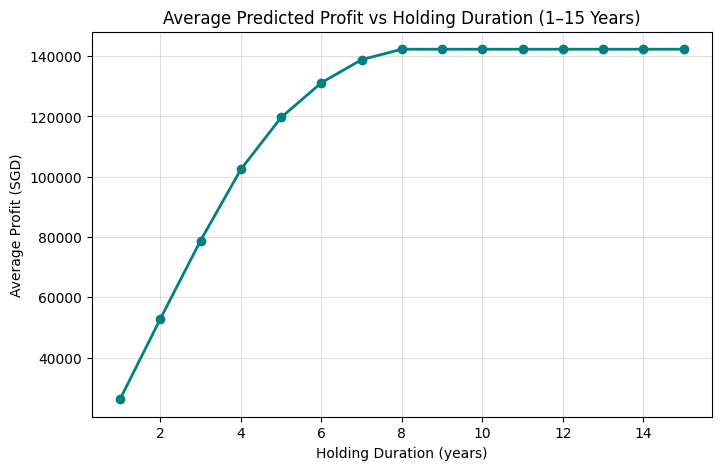

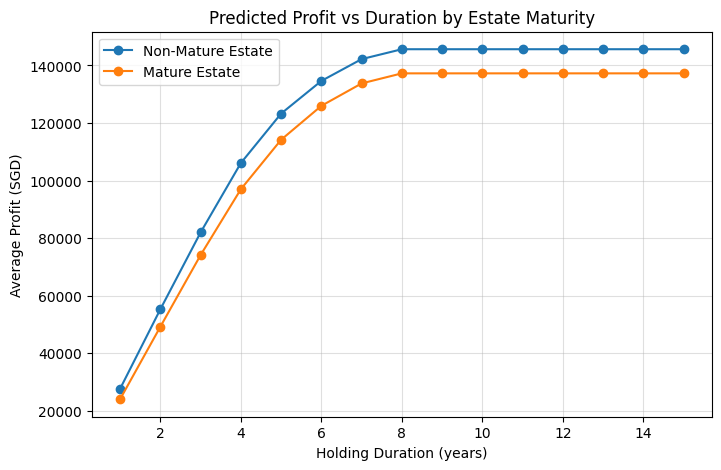

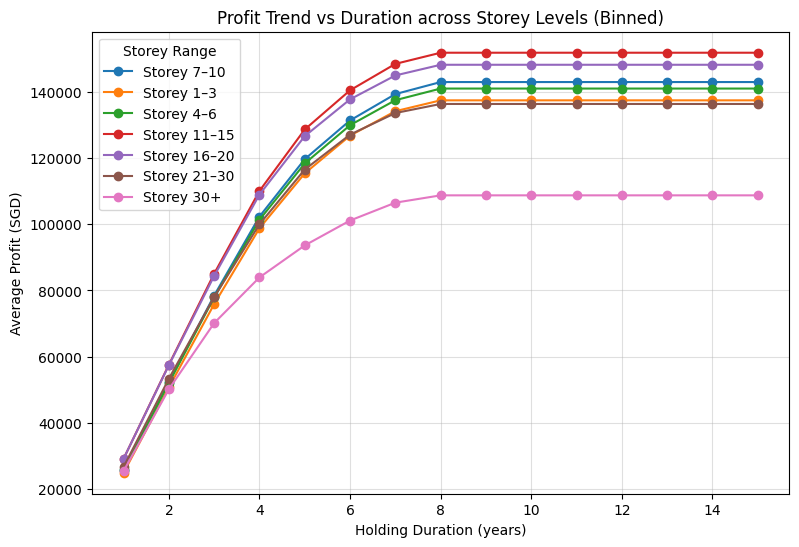

C:\Users\cavan\AppData\Local\Temp\ipykernel_46344\3337522161.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Floor_Area_Range")[[f"ProfitPct_{k}yr" for k in range(1, 16)]]


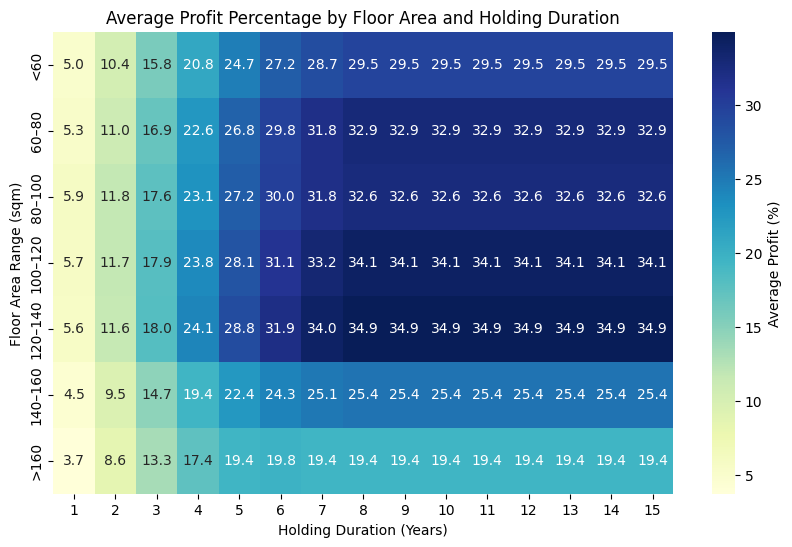

In [27]:
# Mean profit for each duration (1–15 years)
durations = range(1, 16)
avg_profit_by_duration = {k: df[f"Profit_{k}yr"].mean() for k in durations}

plt.figure(figsize=(8,5))
plt.plot(list(avg_profit_by_duration.keys()),
         list(avg_profit_by_duration.values()),
         marker='o', color='teal', linewidth=2)
plt.title("Average Predicted Profit vs Holding Duration (1–15 Years)")
plt.xlabel("Holding Duration (years)")
plt.ylabel("Average Profit (SGD)")
plt.grid(True, alpha=0.4)
plt.show()

#Profit trend by maturity
plt.figure(figsize=(8,5))
for maturity_label, group in df.groupby("Mature"):
    profits = [group[f"Profit_{k}yr"].mean() for k in durations]
    label = "Mature Estate" if maturity_label else "Non-Mature Estate"
    plt.plot(durations, profits, marker='o', label=label)

plt.title("Predicted Profit vs Duration by Estate Maturity")
plt.xlabel("Holding Duration (years)")
plt.ylabel("Average Profit (SGD)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

#Profit trend by storey levels
bins = [0, 3, 6, 10, 15, 20, 30, 50]
labels = ["1–3", "4–6", "7–10", "11–15", "16–20", "21–30", "30+"]
df["Storey_Bin"] = pd.cut(df["Storey"], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(9,6))

for level in df["Storey_Bin"].unique():
    subset = df[df["Storey_Bin"] == level]
    profits = [subset[f"Profit_{k}yr"].mean() for k in durations]
    plt.plot(durations, profits, marker='o', label=f"Storey {level}")

plt.title("Profit Trend vs Duration across Storey Levels (Binned)")
plt.xlabel("Holding Duration (years)")
plt.ylabel("Average Profit (SGD)")
plt.legend(title="Storey Range")
plt.grid(True, alpha=0.4)
plt.show()


#Heatmap for floor area and duration
profitpct_by_area = (
    df.groupby("Floor_Area_Range")[[f"ProfitPct_{k}yr" for k in range(1, 16)]]
    .mean()
    .round(2)
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    profitpct_by_area,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Average Profit (%)'},
    xticklabels=[str(k) for k in range(1, 16)],
    yticklabels=profitpct_by_area.index
)
plt.title("Average Profit Percentage by Floor Area and Holding Duration")
plt.xlabel("Holding Duration (Years)")
plt.ylabel("Floor Area Range (sqm)")
plt.show()

# **Results Explanation**

**Average Predicted Profit vs Holding Duration (1–15 Years)**, **Predicted Profit vs Duration by Estate Maturity**, **Profit Trend vs Duration across Storey Levels (Binned)**

Across these three graphs, it shows that the optimal time of selling one's house is 8 years, as the appreciation of the house plateaus after 8 years. Given the same holding duration range, non mature units sell higher than mature units, and middle level bins of 11-15 and 16-20 sell the highest, followed by lower level bins like 1-3, 4-6, 7-10, and the highest level bins of 21-30 and 30+ selling the lowest.

**Average Profit Percentage by Floor Area and Holding Duration**
This heatmap is used to show the profit percentage by floor area and holding duration, where the average profitability by percentage increases as the heatmap gets darker. 

Flats between 80–120 sqm show the highest profit percentages (darkest blue), peaking around 34–35% after ~10 years.
Smaller units (<60 sqm) yield lower profit percentages (~29% max), likely because they start from lower base values and have less room for price appreciation.
Very large flats (>160 sqm) show lower returns (~19%), despite high absolute prices — consistent with luxury or niche flat segments having lower resale demand.



# **Conclusion**

The best unit types and duration to maximise profits for homeowners are:
- **8 years**
- **Non-mature estate**
- **80-120 sqm**
- **11-15 storeys**

This trend generally tells us that middle range houses in terms of storeys and floor area tend to sell the best